# Galaxy10 DECals Classification - Deep Learning Milestone 1

## Table of Contents

- [Imports](#Imports)
- [Load Data](#Load-Data)
- [Visualization of class distribution](#Visualization-of-class-distribution)
- [K-Fold Cross Validation](#K-Fold-Cross-Validation)

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from astroNN.datasets import load_galaxy10
from tensorflow.keras import utils
from tensorflow.random import set_seed
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, TensorBoard
import os

## Load Data

In [2]:
# To load images and labels (will download automatically at the first time)
# First time downloading location will be ~/.astroNN/datasets/
images, labels = load_galaxy10()

# To convert the labels to categorical 10 classes
labels = utils.to_categorical(labels, 10)

# To convert to desirable type
labels = labels.astype(np.float32)
images = images.astype(np.float32)

label_dict = {
    0: "Disturbed Galaxies",
    1: "Merging Galaxies",
    2: "Round Smooth Galaxies",
    3: "In-between Round Smooth Galaxies",
    4: "Cigar Shaped Smooth Galaxies",
    5: "Barred Spiral Galaxies",
    6: "Unbarred Tight Spiral Galaxies",
    7: "Unbarred Loose Spiral Galaxies",
    8: "Edge-on Galaxies without Bulge",
    9: "Edge-on Galaxies with Bulge"
}

# One-Hot → Klassenindex
class_indices = np.argmax(labels, axis=1)

# Ausgabe
print(f"{'Klasse':<8} {'Beschreibung':<40} {'Anzahl':>7}")
print("-" * 58)

counts = {}

for cls_id, cls_name in label_dict.items():
    count = np.sum(class_indices == cls_id)
    counts[cls_id] = count
    print(f"{cls_id:<8} {cls_name:<40} {count:>7}")

print("-" * 58)
print(f"{'GESAMT':<48} {len(class_indices):>7}")

C:\Users\U0127627\.astroNN\datasets\Galaxy10_DECals.h5 was found!
Klasse   Beschreibung                              Anzahl
----------------------------------------------------------
0        Disturbed Galaxies                          1081
1        Merging Galaxies                            1853
2        Round Smooth Galaxies                       2645
3        In-between Round Smooth Galaxies            2027
4        Cigar Shaped Smooth Galaxies                 334
5        Barred Spiral Galaxies                      2043
6        Unbarred Tight Spiral Galaxies              1829
7        Unbarred Loose Spiral Galaxies              2628
8        Edge-on Galaxies without Bulge              1423
9        Edge-on Galaxies with Bulge                 1873
----------------------------------------------------------
GESAMT                                             17736


## Visualization of class distribution

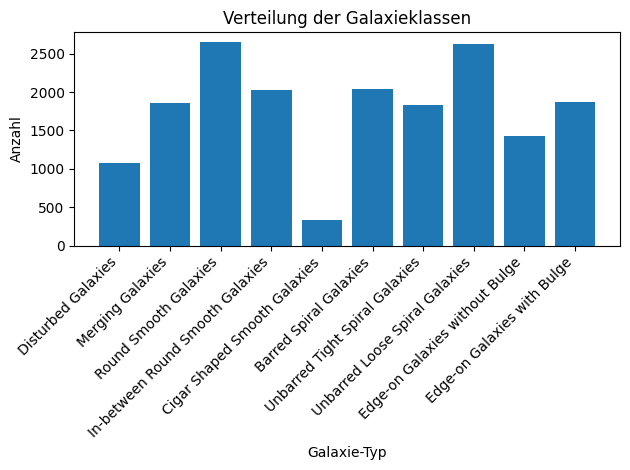

In [3]:
class_names = [label_dict[i] for i in label_dict.keys()]
values = [counts[i] for i in label_dict.keys()]

plt.figure()
plt.bar(range(len(values)), values)

plt.xticks(range(len(values)), class_names, rotation=45, ha='right')
plt.xlabel("Galaxie-Typ")
plt.ylabel("Anzahl")
plt.title("Verteilung der Galaxieklassen")

plt.tight_layout()
plt.show()

## K-Fold Cross Validation

In [4]:
# Reproduzierbarkeit
RANDOM_STATE = 42

# Labels (wie vorher)
y = class_indices

# Use images array as X
X = images

# --- 1. Test-Set abtrennen (einmal fix) ---
# We use indices so later folds refer to indices into X and y
X_temp, X_test, y_temp, y_test = train_test_split(
    np.arange(len(y)),  # indices
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Train+Val: {len(X_temp)} | Test: {len(X_test)}")

# --- 2. K-Fold Cross Validation auf Train+Val ---
k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

folds = []

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_temp, y_temp)):
    # train_idx/val_idx are positions within X_temp; convert to absolute indices
    train_indices = X_temp[train_idx]
    val_indices = X_temp[val_idx]

    folds.append((train_indices, val_indices))

    print(f"\nFold {fold_idx + 1}")
    print(f"Train: {len(train_indices)} | Val: {len(val_indices)}")

# Zugriff später:
# folds[0] → erstes (train, val)-Paar

Train+Val: 14188 | Test: 3548

Fold 1
Train: 11350 | Val: 2838

Fold 2
Train: 11350 | Val: 2838

Fold 3
Train: 11350 | Val: 2838

Fold 4
Train: 11351 | Val: 2837

Fold 5
Train: 11351 | Val: 2837


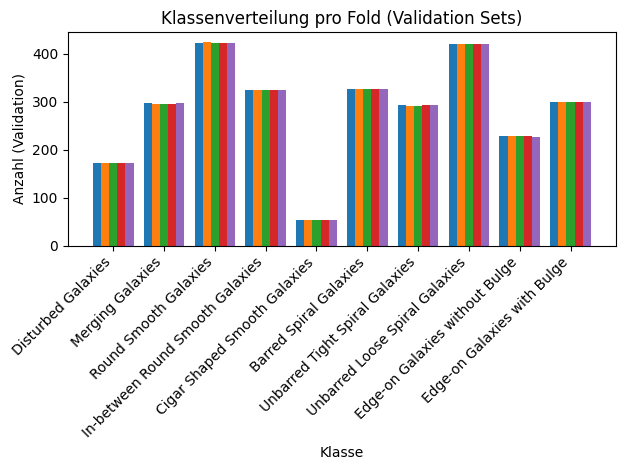

In [5]:
num_classes = len(label_dict)
k = len(folds)

# Matrix: [fold, klasse]
fold_class_counts = np.zeros((k, num_classes))

for fold_idx, (_, val_idx) in enumerate(folds):
    y_val = y[val_idx]
    for cls in range(num_classes):
        fold_class_counts[fold_idx, cls] = np.sum(y_val == cls)

# Plot
x = np.arange(num_classes)
width = 0.8 / k  # Balkenbreite abhängig von Anzahl Folds

plt.figure()

for fold_idx in range(k):
    plt.bar(x + fold_idx * width, fold_class_counts[fold_idx], width)

# Achsen & Labels
class_names = [label_dict[i] for i in range(num_classes)]
plt.xticks(x + width * (k - 1) / 2, class_names, rotation=45, ha='right')

plt.xlabel("Klasse")
plt.ylabel("Anzahl (Validation)")
plt.title("Klassenverteilung pro Fold (Validation Sets)")

plt.tight_layout()
plt.show()

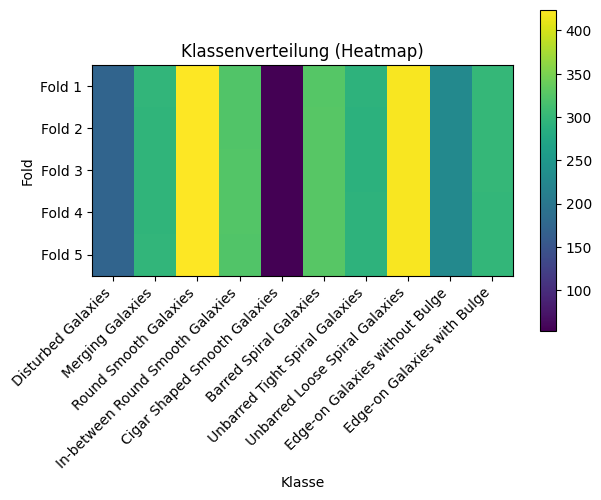

In [6]:
plt.figure()
plt.imshow(fold_class_counts)

plt.colorbar()
plt.xlabel("Klasse")
plt.ylabel("Fold")
plt.title("Klassenverteilung (Heatmap)")

plt.xticks(range(num_classes), [label_dict[i] for i in range(num_classes)], rotation=45, ha='right')
plt.yticks(range(k), [f"Fold {i+1}" for i in range(k)])

plt.tight_layout()
plt.show()

In [7]:
# Reproduzierbarkeit
SEED = 42
set_seed(SEED)
np.random.seed(SEED)

BATCH_SIZE = 32
EPOCHS = 10
LR = 1e-3

NUM_CLASSES = len(label_dict)
INPUT_SHAPE = X.shape[1:]

os.makedirs('./logs', exist_ok=True)

# --- Modell-Builder ---
def build_model():
    """Erzeugt ein frisch initialisiertes Modell.
    Wird pro Fold neu aufgerufen, damit jeder Fold
    mit zufälligen Gewichten startet.
    """
    model = Sequential([
        Input(shape=INPUT_SHAPE),
        Conv2D(32,  kernel_size=37, activation='relu'),
        Conv2D(64,  kernel_size=27, activation='relu'),
        MaxPooling2D(pool_size=(2, 2), strides=2),
        Conv2D(128, kernel_size=17, activation='relu'),
        MaxPooling2D(pool_size=(2, 2), strides=2),
        Conv2D(256, kernel_size=7,  activation='relu'),
        MaxPooling2D(pool_size=(2, 2), strides=2),
        Conv2D(512, kernel_size=3,  activation='relu'),
        MaxPooling2D(pool_size=(2, 2), strides=2),
        Flatten(),
        Dense(256, activation='relu'),
        Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=LR),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# Einmalige Ausgabe der Architektur zur Kontrolle
build_model().summary()

# --- Training pro Fold ---
def train_fold(fold_idx, X, y, train_idx, val_idx):
    """Trainiert ein NEUES Modell auf einem einzelnen Fold.

    WICHTIG: build_model() wird hier aufgerufen, nicht außerhalb.
    Würde man dasselbe Modell-Objekt für alle Folds wiederverwenden,
    würde jeder Fold auf den Gewichten des vorherigen aufbauen –
    das würde die Unabhängigkeit der Folds zerstören.
    """
    # Frisches Modell für diesen Fold
    fold_model = build_model()

    X_train, y_train = X[train_idx], y[train_idx]
    X_val,   y_val   = X[val_idx],   y[val_idx]

    # Fold-spezifische Pfade, damit Folds sich nicht gegenseitig überschreiben
    cp = ModelCheckpoint(
        filepath=f'./logs/checkpoint_fold{fold_idx + 1}.keras',
        save_best_only=True,
        monitor='val_accuracy',
        verbose=0
    )
    tb = TensorBoard(log_dir=f'./logs/fold{fold_idx + 1}')

    history = fold_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1,
        callbacks=[cp, tb]
    )

    return fold_model, history

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 220, 220, 32)   │       131,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 194, 194, 64)   │     1,493,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 97, 97, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 81, 81, 128)    │     2,367,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 34, 34, 256)    │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 15, 15, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,203,530 (50.37 MB)

 Trainable params: 13,203,530 (50.37 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
fold_models = []   # Umbenannt von 'models', um Namenskollision zu vermeiden
fold_histories = []

for fold_idx, (train_idx, val_idx) in enumerate(folds):
    print(f"\n===== Fold {fold_idx + 1} / {len(folds)} =====")

    # train_fold erstellt intern ein frisches Modell –
    # kein Modell-Objekt wird hier übergeben.
    _model, history = train_fold(fold_idx, X, y, train_idx, val_idx)

    fold_models.append(_model)
    fold_histories.append(history)

print("\n✓ Alle Folds abgeschlossen.")


===== Fold 1 / 5 =====
Epoch 1/10


In [ ]:
test_accuracies = []

# 'fold_model' statt 'model' als Loop-Variable, damit die äußere Variable
# 'model' nicht überschrieben wird (Variable-Shadowing-Bug).
for i, fold_model in enumerate(fold_models):
    loss, acc = fold_model.evaluate(X[X_test], y[X_test], verbose=0)
    test_accuracies.append(acc)
    print(f"Fold {i + 1} Test Accuracy: {acc:.4f}")

print(f"\nDurchschnittliche Test Accuracy: {np.mean(test_accuracies):.4f}")
print(f"Standardabweichung:              {np.std(test_accuracies):.4f}")